In [1]:

import Pkg; Pkg.add("BenchmarkTools")
import Pkg; Pkg.add("Revise")
import Pkg; Pkg.add("BifurcationKit")
import Pkg; Pkg.add(url="https://github.com/johnfgibson/CloudAtlas.jl")
import BifurcationKit as BK
import Pkg; Pkg.add("PlotlyJS")
using CloudAtlas
using LinearAlgebra, Polynomials, Plots, DelimitedFiles, BenchmarkTools, Revise

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed Xorg_libpciaccess_jll ─ v0.18.1+0
   Installed libdrm_jll ──────────── v2.4.125+1
   Installed libva_jll ───────────── v2.23.0+0
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Updating `~/.julia/environments/v1.12/Manifest.toml`
  [a65dc6b1] + Xorg_libpciaccess_jll v0.18.1+0
  [8e53e030] + libdrm_jll v2.4.125+1
  [9a156e7d] + libva_jll v2.23.0+0
Precompiling packages...
    326.3 ms  ✓ Xorg_libpciaccess_jll
    239.3 ms  ✓ libdrm_jll
    237.6 ms  ✓ libva_jll
  3 dependencies successfully precompiled in 2 seconds. 318 already precompiled.
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed f

In [2]:
"""
    myreaddlm(filename, cc='%')

Read matrix or vector from a file, dropping comments marked with cc.
"""
function myreaddlm(filename; cc='%')
    X = readdlm(filename, comments=true, comment_char=cc)
    if size(X,2) == 1
        X = X[:,1]
    end
    X
end

sx, sy, sz, tx, tz = halfbox_symmetries()       #performs a set of flips in s, and translations in t


pwd()

"/Users/samgeho/Desktop/TECH 412"

In [3]:
α, γ = 1.0, 2.0
#store = [5][1:3]
#α, γ = store[5][1], store[5][2]                    # Fourier wavenumbers α, γ = 2π/Lx, 2π/Lz
J,K,L = 1,2,3                       # Bounds on Fourier modes (J,K) and wall-normal polynomials (L)
H = [sx*sy*sz, sz*tx*tz]          # Generators of the symmetric subspace of the Nagata eqb
println(H)

model = ODEModel(α, γ, J, K, L, H)  # Construct ODE model by Galerkin projection 

@show m = length(model);            # dimension of ODE model

Symmetry[Symmetry(-1, -1, -1, 0//1, 0//1, 1), Symmetry(1, 1, -1, 1//2, 1//2, 1)]
J,K,L,m == 1,2,3,27
(2J+1)(2K+1)(2L+1) + 1 == 106
Making matrices B,A1,A2,S3...
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 
m = length(model) = 27


In [4]:
xguess = myreaddlm("/Users/samgeho/Desktop/TECH 412/xeq1projection-Re200-1-2-3-27d.asc")
#xguess = store[5][3]
R = 200
@show norm(model.f(xguess, R));

norm(model.f(xguess, R)) = 0.00952405613492764


In [5]:
fr = x -> model.f(x,R)    # define function  f(x) = f(x,R)  for fixed R
Dfr = x -> model.Df(x,R)  # define function Df(x) = Df(x,R) for fixed R

@time xeq1, eq1success = hookstepsolve(fr, Dfr, xguess)

@show norm(fr(xeq1))/norm(xeq1);

  0.322582 seconds (1.80 M allocations: 90.223 MiB, 99.28% compilation time)
norm(fr(xeq1)) / norm(xeq1) = 2.6957273378749696e-10


In [6]:
myshear = x -> shear(x,model) ###one with fixed basis I=myshear(xeq1)
myshear(xeq1)

1.6460527034370973

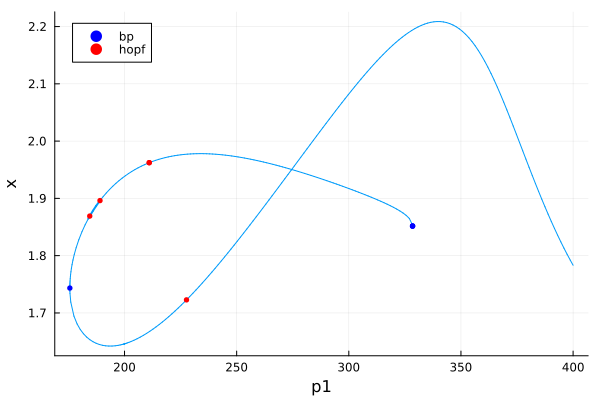

In [7]:
fp(x,p) = model.f(x,p[1])
prob1 = BK.BifurcationProblem(fp,
        xeq1,         # initial condition x0
        [Float64(R)], # set of parameters
        1;            # parameter index for continuation
        #record_from_solution = (x,p; k...) -> shear(x),
        plot_solution = (x,p; k...) -> myshear(x),
        record_from_solution = (x,p; k...) -> myshear(x),
    )

newtopts = BK.NewtonPar(1e-10, 25, false, BK.DefaultLS(), BK.DefaultEig(), false, 1.0, 0.01)
contopts = BK.ContinuationPar(p_min = 100., p_max = 400., n_inversion=20, dsmin=1e-12, dsmax=1.0, 
    max_steps = 200, newton_options = newtopts)

br1 = BK.continuation(prob1, BK.PALC(), contopts, bothside=true)

plot(br1)
#println(α)
#println(γ)

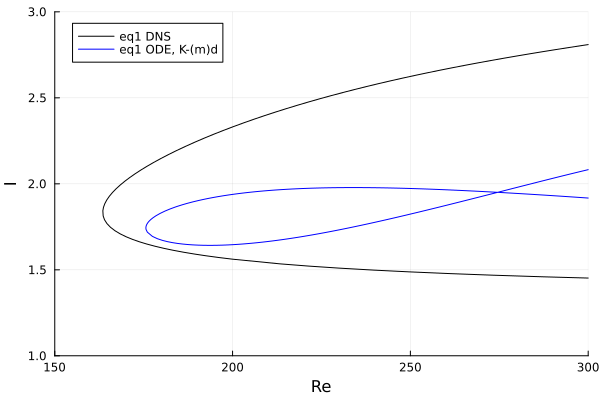

In [8]:
ReD1 = [br1.param br1.x];

eq1ReD = myreaddlm("/Users/samgeho/Desktop/TECH 412/eq1ReD-DNS.asc", cc='#')
plot(eq1ReD[:,1], eq1ReD[:,2], color=:black, label="eq1 DNS")
plot!(ReD1[:,1], ReD1[:,2], color=:blue, label="eq1 ODE, K-(m)d")
#plot!(ReD2[:,1], ReD2[:,2], color=:blue, label="")
plot!(xlabel="Re", ylabel="I", xlim=(150,300), ylim=(1,3))  

J,K,L,m == 1,2,3,27
(2J+1)(2K+1)(2L+1) + 1 == 106
Making matrices B,A1,A2,S3...
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 
norm(model.f(xguess, R)) = 0.009482757127376817
  0.051453 seconds (82.06 k allocations: 4.945 MiB, 97.94% compilation time)
0.26937931830154244
norm(fr(xeq1)) / norm(xeq1) = 7.50583661721017e-9
J,K,L,m == 1,2,3,27
(2J+1)(2K+1)(2L+1) + 1 == 106
Making matrices B,A1,A2,S3...
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 
norm(model.f(xguess, R)) = 0.0006089262655059683
  0.000479 seconds (452 allocations: 145.812 KiB)
0.2702889242098518
norm(fr(xeq1)) / norm(xeq1) = 3.230408270728888e-11
J,K,L,m == 1,2,3,27
(2J+1)(2K+1)(2L+1) + 1 == 106
Making matrices B,A1,A2,S3...
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 
norm(model.f(xguess, R)) = 0.0006288205941504785
  0.000482 seconds (452 allocation

┌ Error: Newton failed to fully locate bifurcation point using bisection parameters!
└ @ BifurcationKit ~/.julia/packages/BifurcationKit/q52qN/src/Bifurcations.jl:210


J,K,L,m == 1,2,3,27
(2J+1)(2K+1)(2L+1) + 1 == 106
Making matrices B,A1,A2,S3...
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 
norm(model.f(xguess, R)) = 0.001331155198750469
  0.007268 seconds (452 allocations: 145.844 KiB, 93.00% gc time)
0.35366209114481123
norm(fr(xeq1)) / norm(xeq1) = 4.0667473688926306e-11
J,K,L,m == 1,2,3,27
(2J+1)(2K+1)(2L+1) + 1 == 106
Making matrices B,A1,A2,S3...
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 
norm(model.f(xguess, R)) = 0.0013669945105171096
  0.000432 seconds (452 allocations: 145.812 KiB)
0.35811845654217483
norm(fr(xeq1)) / norm(xeq1) = 9.048264632465676e-12
J,K,L,m == 1,2,3,27
(2J+1)(2K+1)(2L+1) + 1 == 106
Making matrices B,A1,A2,S3...
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 
norm(model.f(xguess, R)) = 0.0013992215916660538
  0.000452 seconds (452 allocations: 145.

┌ Error: Failure to converge with given tolerance = 1.0e-10.
│ Step = 160
│ You can decrease the tolerance or pass a different norm using the argument `normC`.
│ We reached the smallest value [dsmin] valid for ds, namely 1.0e-12.
│ Stopping continuation at continuation step 160.
└ @ BifurcationKit ~/.julia/packages/BifurcationKit/q52qN/src/continuation/Contbase.jl:70


J,K,L,m == 1,2,3,27
(2J+1)(2K+1)(2L+1) + 1 == 106
Making matrices B,A1,A2,S3...
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 
norm(model.f(xguess, R)) = 0.000837311026339316
  0.000587 seconds (453 allocations: 146.125 KiB)
0.29652987411886766
norm(fr(xeq1)) / norm(xeq1) = 6.043279603673296e-10
J,K,L,m == 1,2,3,27
(2J+1)(2K+1)(2L+1) + 1 == 106
Making matrices B,A1,A2,S3...
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 
norm(model.f(xguess, R)) = 0.0009090502827405511
  0.000491 seconds (453 allocations: 146.094 KiB)
0.30602466625678154
norm(fr(xeq1)) / norm(xeq1) = 1.5578681555037444e-9
J,K,L,m == 1,2,3,27
(2J+1)(2K+1)(2L+1) + 1 == 106
Making matrices B,A1,A2,S3...
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 
norm(model.f(xguess, R)) = 0.000991859705577818
  0.000463 seconds (453 allocations: 146.094 KiB)
0.3164916

...


Stopping continuation.

J,K,L,m == 1,2,3,27
(2J+1)(2K+1)(2L+1) + 1 == 106
Making matrices B,A1,A2,S3...
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 
norm(model.f(xguess, R)) = 0.01374981345072629
  0.003629 seconds (7.59 k allocations: 7.076 MiB)
0.2717327964749222
norm(fr(xeq1)) / norm(xeq1) = 0.00032978131918525436

Newton failed to converge for the initial guess on the branch. Residuals:


26-element Vector{Float64}:
  8.961240008739809e-5
 69.67972099101921
 17.4199409679953
  4.354993899363151
  1.0888521957013682
  0.27222322115518954
  0.06791775346291992
  0.017366202868955054
  0.004590150687831318
  0.0014165731229639435
  0.0007894002686978494
  0.010478882415066912
  0.002832987943976328
  0.0009788065480202028
  0.0012291595036053847
  0.0008485867554498446
  0.0027904805623453982
  0.0009702383437371741
  0.001264132990544632
  0.0008321998704321356
  0.003597361036672437
  0.0011499883980521715
  0.0009035311784007783
  0.0017084446683685835
  0.0007893943102717908
  0.029261488695718964


Stopping continuation.

J,K,L,m == 1,2,3,27
(2J+1)(2K+1)(2L+1) + 1 == 106
Making matrices B,A1,A2,S3...
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 
norm(model.f(xguess, R)) = 0.012981406105502644
  0.004212 seconds (7.26 k allocations: 6.722 MiB)
0.27665237388625535
norm(fr(xeq1)) / norm(xeq1) = 0.000107546320148367

Newton failed to converge for the initial guess on the branch. Residuals:


26-element Vector{Float64}:
 2.9752944771776944e-5
 3.071964323837713
 0.7679836942944887
 0.1921232439173401
 0.04810346260407671
 0.013191072170128553
 0.0031753671796570368
 0.001181898226992156
 0.000258462896493795
 0.000609036175846759
 0.0002616944596962847
 0.002114182706258659
 0.0006008790719025212
 0.0002605545830658467
 0.002777502105973863
 0.000764400362264867
 0.0002864472227004321
 0.0006408675125080925
 0.0002657097169358275
 0.0015660513730649632
 0.00046746224022163336
 0.00025645208612227956
 0.008167800704750395
 0.0021076051944790464
 0.0005992446651231782
 0.0002603598761827536


Stopping continuation.

J,K,L,m == 1,2,3,27
(2J+1)(2K+1)(2L+1) + 1 == 106
Making matrices B,A1,A2,S3...
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 
norm(model.f(xguess, R)) = 0.01220921784794543
  0.001262 seconds (1.48 k allocations: 1.075 MiB)
0.27272826372477915
norm(fr(xeq1)) / norm(xeq1) = 3.7774602128102536e-13
J,K,L,m == 1,2,3,27
(2J+1)(2K+1)(2L+1) + 1 == 106
Making matrices B,A1,A2,S3...
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 
norm(model.f(xguess, R)) = 0.0004953867404931717
  0.000538 seconds (553 allocations: 189.391 KiB)
0.2700778441968432
norm(fr(xeq1)) / norm(xeq1) = 1.62877217714979e-12
J,K,L,m == 1,2,3,27
(2J+1)(2K+1)(2L+1) + 1 == 106
Making matrices B,A1,A2,S3...
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 
norm(model.f(xguess, R)) = 0.0004839283067194243
  0.000500 seconds (452 allocation

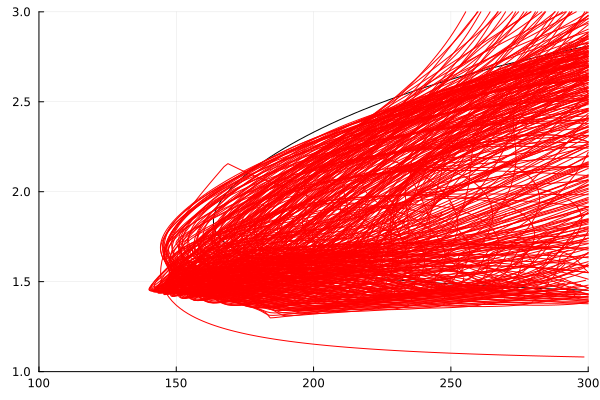

In [9]:
α, γ = 1.05, 2.05
R=200

xguess = myreaddlm("/Users/samgeho/Desktop/TECH 412/xeq1-Re200-1-2-3.asc")
eq1ReD = myreaddlm("/Users/samgeho/Desktop/TECH 412/eq1ReD-DNS.asc", cc='#') #I put this in! Don't trust!

numTests = 0

my_vector = []
store = []
plotData = []
alpha_vector = []
gamma_vector = []
plot(eq1ReD[:,1], eq1ReD[:,2], color=:black, xlim = (125,300), ylim = (1,3), label="")
#plot(eq1ReD[:,1], eq1ReD[:,2], color=:black, label="eq DNS") I deleted label="eq DNS"

for i in 0:0.05:0.5
    #xguess = myreaddlm("/Users/samgeho/Desktop/TECH 412/xeq1projection-Re200-1-2-3-27d.asc")
    #eq1ReD = myreaddlm("/Users/samgeho/Desktop/TECH 412/eq1ReD-DNS.asc", cc='#') #I put this in! Don't trust!
    α -= 0.05
    γ = 2.05

    push!(alpha_vector, α)
    #@show a
    for j in 0:0.05:1
        try
            γ -= 0.05
            if α == 1.0
                push!(gamma_vector, γ)
            end
            J,K,L = 1,2,3  #1,2,3  #1,1,3       # Bounds on Fourier modes (J,K) and wall-normal polynomials (L)
            H = [sx*sy*sz, sz*tx*tz]            # Generators of the symmetric subspace of the Nagata eqb
            
            model = ODEModel(α, γ, J, K, L, H, normalize=true)  # Construct ODE model by Galerkin projection 
            
            #@show m = length(model)
            #@show x = length(xguess)
            @show norm(model.f(xguess, R));
            
            fr = x -> model.f(x,R)    # define function  f(x) = f(x,R)  for fixed R
            Dfr = x -> model.Df(x,R)  # define function Df(x) = Df(x,R) for fixed R
            
            @time xeq1, eq1success = hookstepsolve(fr, Dfr, xguess)

            println(norm(xeq1))
            
                
            @show norm(fr(xeq1))/norm(xeq1);
            
            shear(xeq1, model)
            
            myshear = x -> shear(x,model) ###one with fixed basis I=myshear(xeq1)
            I = myshear(xeq1)
            push!(plotData, [sqrt((2*pi/α)^2 + (2*pi/γ)^2), I])
            fp(x,p) = model.f(x,p[1])
            prob1 = BK.BifurcationProblem(fp,
                xeq1,         # initial condition x0
                [Float64(R)], # set of parameters
                1;            # parameter index for continuation
                #record_from_solution = (x,p; k...) -> shear(x),
                plot_solution = (x,p; k...) -> myshear(x),
                record_from_solution = (x,p; k...) -> myshear(x),
                )
            
            newtopts = BK.NewtonPar(1e-10, 25, false, BK.DefaultLS(), BK.DefaultEig(), false, 1.0, 0.01)
            contopts = BK.ContinuationPar(p_min = 0., p_max = 400., n_inversion=20, dsmin=1e-12, dsmax=1.0, 
                max_steps = 200, newton_options = newtopts)
                
            br1 = BK.continuation(prob1, BK.PALC(), contopts, bothside=true)
                
            #plot(br1)
            
            #push!(my_matrix, [R, α, γ, xguess])

            ReD1 = [br1.param br1.x];
            #xguess = xeq1
            if minimum(ReD1) > 1.1
                push!(my_vector, [minimum(ReD1[:,1])]) 
                xguess = xeq1
                push!(store, [α, γ, xeq1])
            else
                push!(my_vector, [0.0])
                push!(store, [α, γ, xguess])
            end

            #eq1ReD = ReD1 #I put this in! don't trust!

            eq1ReD = myreaddlm("/Users/samgeho/Desktop/TECH 412/eq1ReD-DNS.asc", cc='#') #uncomment if does not work
            #plot(eq1ReD[:,1], eq1ReD[:,2], color=:black, label="eq1 DNS")
            #plot!(ReD1[:,1], ReD1[:,2], color=:blue, xlim = (125,300), ylim = (1,3), label="")
            #plot!(ReD1[:,1], ReD1[:,2], color=:blue, label="eq1 ODE, K-(m)d")
            #plot!(ReD2[:,1], ReD2[:,2], color=:blue, label="")
            #plot!(xlabel="Re", ylabel="I", xlim=(150,300), ylim=(1,3)) 
            #push!(my_vector, [minimum(ReD1[:,1])])  
            #######
            #plot!(x, y, color=:green, label = "xxx")
            plot!(ReD1[:,1], ReD1[:,2], color=:red, xlim = (100,300), ylim = (1,3), label="")####### I'm still using this one!

            numTests += 1
        
        catch e
            println()
            println(e)
            println()
            numTests += 1
            push!(my_vector, [0.0])
            push!(store, [α, γ, xguess])
        end

    end
end
plot!(ReD1[:,1], ReD1[:,2], color=:red, xlim = (100,300), ylim = (1,3), label="")


#plot!()

#@show numTests
#@show my_vector
    

In [10]:
@show my_vector
my_matrix = Matrix{Vector{Float64}}(reshape(my_vector, 21,:))
display(my_matrix)
#show store
#@show alpha_vector, gamma_vector
#@show gamma_vector
@show alpha_vector
#println("minimum alpha: ", minimum(alpha_vector), ", maximum alpha: ", maximum(alpha_vector), ", length of vector: ", length(alpha_vector))
#println("minimum gamma: ", minimum(gamma_vector), ", maximum gamma: ", maximum(gamma_vector), ", length of vector: ", length(gamma_vector))

my_vector = Any[[175.6267701965036], [169.8773217746025], [165.3780992640297], [161.90954584611532], [159.03788433401314], [156.44802375381212], [154.03474689432215], [151.78427738052102], [149.70391035755293], [147.80130421716356], [146.0808736292862], [144.5451212969788], [143.19780598230687], [142.04840415113082], [141.11781105792593], [140.4447990707102], [140.09220518542404], [140.15145808757066], [140.74463617670273], [142.02444324014684], [144.17373857548134], [174.63437041130535], [168.13097260932287], [162.76844109720508], [158.70134597131982], [155.91718946958082], [153.97824425629935], [152.34509762293794], [150.78985802820958], [149.2828725906544], [147.84664056716613], [146.50774575440587], [145.28698158780026], [144.1999961782637], [143.2612044722528], [142.48964931223273], [141.91669194661782], [141.59495198391352], [141.60692587682726], [142.07115095812122], [143.14461447877963], [145.02226310471758], [176.62798563417869], [169.40608404985545], [163.09542835462642], [15

21×11 Matrix{Vector{Float64}}:
 [175.627]  [174.634]  [176.628]  …  [0.0]      [0.0]      [0.0]
 [169.877]  [168.131]  [169.406]     [0.0]      [0.0]      [0.0]
 [165.378]  [162.768]  [163.095]     [0.0]      [0.0]      [0.0]
 [161.91]   [158.701]  [157.871]     [0.0]      [0.0]      [0.0]
 [159.038]  [155.917]  [153.982]     [193.628]  [0.0]      [0.0]
 [156.448]  [153.978]  [151.599]  …  [184.102]  [198.751]  [0.0]
 [154.035]  [152.345]  [150.36]      [175.244]  [188.699]  [0.0]
 [151.784]  [150.79]   [149.508]     [167.168]  [179.418]  [194.937]
 [149.704]  [149.283]  [148.665]     [159.972]  [171.004]  [185.193]
 [147.801]  [147.847]  [147.783]     [153.762]  [163.519]  [176.415]
 [146.081]  [146.508]  [146.896]  …  [148.724]  [157.021]  [168.618]
 [144.545]  [145.287]  [146.045]     [145.323]  [151.622]  [161.812]
 [143.198]  [144.2]    [145.265]     [145.279]  [147.623]  [156.043]
 [142.048]  [143.261]  [144.581]     [153.104]  [146.025]  [151.484]
 [141.118]  [142.49]   [144.017

alpha_vector = Any[1.0, 0.95, 0.8999999999999999, 0.8499999999999999, 0.7999999999999998, 0.7499999999999998, 0.6999999999999997, 0.6499999999999997, 0.5999999999999996, 0.5499999999999996, 0.4999999999999996]


11-element Vector{Any}:
 1.0
 0.95
 0.8999999999999999
 0.8499999999999999
 0.7999999999999998
 0.7499999999999998
 0.6999999999999997
 0.6499999999999997
 0.5999999999999996
 0.5499999999999996
 0.4999999999999996

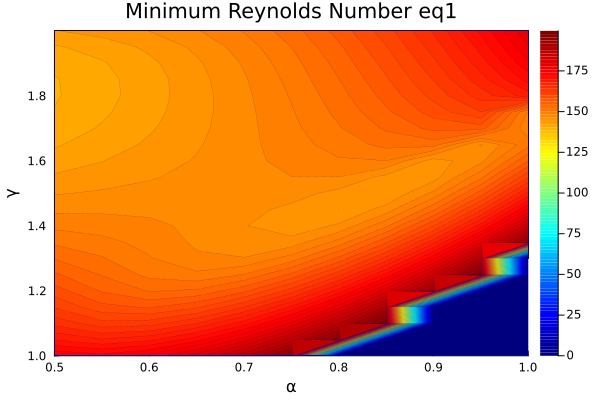

In [53]:
#α, γ
# 1. Define x and y
x = range(minimum(alpha_vector), maximum(alpha_vector), length(alpha_vector))
y = range(minimum(gamma_vector), maximum(gamma_vector), length(gamma_vector))

# 2. Define the matrix
Z = only.(my_matrix)



# 3. Create the contour plot
# Pass x, y, and the function f
contour(x, y, Z, fill=true, colormap=:jet, levels=100, lw = 0.1, title="Minimum Reynolds Number eq1", xlabel="α", ylabel="γ") # 'fill=true' creates filled contours (contourf)
#contour(x, y, Z, fill=true, c=cgrad([:red, :green, :purple]), levels=100, lw = 0.1)
#savefig("min_reynolds_number_alpha_gamma_eq1.png")

In [12]:
@show gamma_vector

gamma_vector = Any[1.9999999999999998, 1.9499999999999997, 1.8999999999999997, 1.8499999999999996, 1.7999999999999996, 1.7499999999999996, 1.6999999999999995, 1.6499999999999995, 1.5999999999999994, 1.5499999999999994, 1.4999999999999993, 1.4499999999999993, 1.3999999999999992, 1.3499999999999992, 1.2999999999999992, 1.2499999999999991, 1.199999999999999, 1.149999999999999, 1.099999999999999, 1.049999999999999, 0.9999999999999989]


21-element Vector{Any}:
 1.9999999999999998
 1.9499999999999997
 1.8999999999999997
 1.8499999999999996
 1.7999999999999996
 1.7499999999999996
 1.6999999999999995
 1.6499999999999995
 1.5999999999999994
 1.5499999999999994
 1.4999999999999993
 1.4499999999999993
 1.3999999999999992
 1.3499999999999992
 1.2999999999999992
 1.2499999999999991
 1.199999999999999
 1.149999999999999
 1.099999999999999
 1.049999999999999
 0.9999999999999989

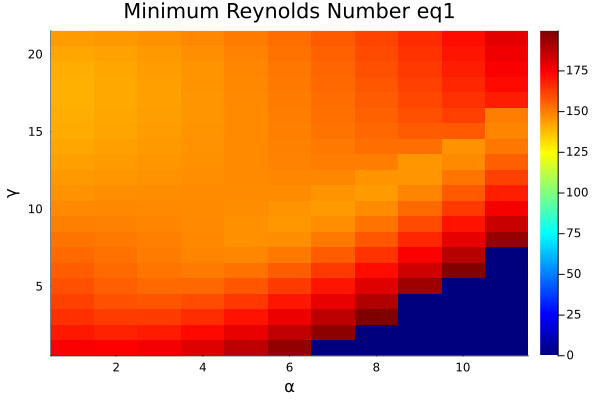

In [49]:
#α, γ
# 1. Define x and y
x = range(minimum(alpha_vector), maximum(alpha_vector), length(alpha_vector))
y = range(minimum(gamma_vector), maximum(gamma_vector), length(gamma_vector))

# 2. Define the matrix
Z = only.(my_matrix)

# 3. Create the contour plot
# Pass x, y, and the function f
heatmap(Z, title="Minimum Reynolds Number eq1", xlabel= "α", ylabel = "γ", fill=true, colormap=:jet) # 'fill=true' creates filled contours (contourf)

In [47]:
@show alpha_vector
display(gamma_vector)

alpha_vector = Any[1.0, 0.95, 0.8999999999999999, 0.8499999999999999, 0.7999999999999998, 0.7499999999999998, 0.6999999999999997, 0.6499999999999997, 0.5999999999999996, 0.5499999999999996, 0.4999999999999996]


21-element Vector{Any}:
 1.9999999999999998
 1.9499999999999997
 1.8999999999999997
 1.8499999999999996
 1.7999999999999996
 1.7499999999999996
 1.6999999999999995
 1.6499999999999995
 1.5999999999999994
 1.5499999999999994
 1.4999999999999993
 1.4499999999999993
 1.3999999999999992
 1.3499999999999992
 1.2999999999999992
 1.2499999999999991
 1.199999999999999
 1.149999999999999
 1.099999999999999
 1.049999999999999
 0.9999999999999989

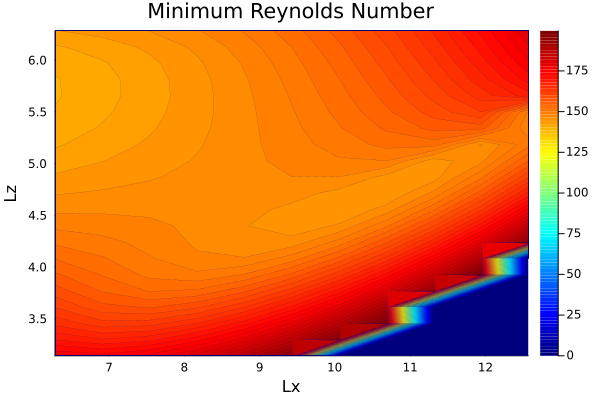

In [54]:
#α, γ
# Fourier wavenumbers α, γ = 2π/Lx, 2π/Lz
#Lx = 2pi/a, Lz = 2pi/y
Lx_vector = []
Lz_vector = []
for i in 1:1:length(alpha_vector)
    #println("Hello!")
    #println(alpha_vector[i])
    Lx = 2pi / alpha_vector[i]
    push!(Lx_vector, Lx)
end
#print(Lx_vector)

for i in 1:1:length(gamma_vector)
    #println("Hello!")
    #println(alpha_vector[i])
    Lz = 2pi / gamma_vector[i]
    push!(Lz_vector, Lz)
end

#print(Lz_vector)
# 1. Define x and y
x = range(minimum(Lx_vector), maximum(Lx_vector), length(Lx_vector))
y = range(minimum(Lz_vector), maximum(Lz_vector), length(Lz_vector))

# 2. Define the matrix
Z = only.(my_matrix)

# 3. Create the contour plot
# Pass x, y, and the function f
contour(x, y, Z, fill=true, colormap=:jet, levels=100, lw = 0.1, title="Minimum Reynolds Number", xlabel="Lx", ylabel="Lz") # 'fill=true' creates filled contours (contourf)
#contour(x, y, Z, fill=true, c=cgrad([:red, :green, :purple]), levels=100, lw = 0.1)
#savefig("min_reynolds_number_Lx_Lz_eq1.png")